In [4]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Cargar dataset
data = load_breast_cancer()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Target
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
import pandas as pd
import numpy as np
import random

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, confusion_matrix

# -------------------------
# 1. CARGAR DATASET
# -------------------------
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# -------------------------
# 2. CREAR TEXTO SIMULADO
# -------------------------
def generar_texto(row):
    if row["mean radius"] > 15:
        return "Paciente con características anormales"
    else:
        return "Paciente sin indicadores críticos"

df["texto"] = df.apply(generar_texto, axis=1)

# -------------------------
# 3. SPLIT
# -------------------------
X_struct = df.drop(columns=["target", "texto"])
y = df["target"]

X_train_struct, X_test_struct, y_train, y_test = train_test_split(
    X_struct, y, test_size=0.2, random_state=42
)

X_train_text = df.loc[X_train_struct.index, "texto"]
X_test_text = df.loc[X_test_struct.index, "texto"]

# -------------------------
# 4. BASELINE (estructurado)
# -------------------------
model_struct = LogisticRegression(max_iter=1000)
model_struct.fit(X_train_struct, y_train)

y_pred_struct = model_struct.predict(X_test_struct)
y_proba_struct = model_struct.predict_proba(X_test_struct)[:,1]

# -------------------------
# 5. MODELO DE TEXTO
# -------------------------
vectorizer = TfidfVectorizer(max_features=100)
X_train_text_vec = vectorizer.fit_transform(X_train_text)
X_test_text_vec = vectorizer.transform(X_test_text)

model_text = LogisticRegression(max_iter=1000)
model_text.fit(X_train_text_vec, y_train)

y_pred_text = model_text.predict(X_test_text_vec)
y_proba_text = model_text.predict_proba(X_test_text_vec)[:,1]

# -------------------------
# 6. LATE FUSION
# -------------------------
y_proba_late = (y_proba_struct + y_proba_text) / 2
y_pred_late = (y_proba_late > 0.5).astype(int)

# -------------------------
# 7. EARLY FUSION
# -------------------------
X_train_combined = np.hstack((X_train_struct, X_train_text_vec.toarray()))
X_test_combined = np.hstack((X_test_struct, X_test_text_vec.toarray()))

model_combined = LogisticRegression(max_iter=1000)
model_combined.fit(X_train_combined, y_train)

y_pred_combined = model_combined.predict(X_test_combined)
y_proba_combined = model_combined.predict_proba(X_test_combined)[:,1]

# -------------------------
# 8. FUNCIÓN MÉTRICAS
# -------------------------
def calcular_metricas(y_true, y_pred, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    auprc = average_precision_score(y_true, y_proba)
    recall = recall_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    f1 = f1_score(y_true, y_pred)

    return round(auc,3), round(auprc,3), round(recall,3), round(specificity,3), round(f1,3)

# -------------------------
# 9. RESULTADOS
# -------------------------
baseline = calcular_metricas(y_test, y_pred_struct, y_proba_struct)
text = calcular_metricas(y_test, y_pred_text, y_proba_text)
late = calcular_metricas(y_test, y_pred_late, y_proba_late)
early = calcular_metricas(y_test, y_pred_combined, y_proba_combined)

# -------------------------
# 10. TABLA FINAL
# -------------------------
tabla = pd.DataFrame({
    "Modelo": ["Baseline estructurado", "Modelo de texto", "Late Fusion", "Early Fusion"],
    "AUC-ROC": [baseline[0], text[0], late[0], early[0]],
    "AUPRC": [baseline[1], text[1], late[1], early[1]],
    "Sensibilidad": [baseline[2], text[2], late[2], early[2]],
    "Especificidad": [baseline[3], text[3], late[3], early[3]],
    "F1-score": [baseline[4], text[4], late[4], early[4]],
})

print(tabla)

C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                  Modelo  AUC-ROC  AUPRC  Sensibilidad  Especificidad  \
0  Baseline estructurado    0.998  0.999         0.986          0.907   
1        Modelo de texto    0.912  0.905         0.986          0.837   
2            Late Fusion    0.996  0.998         1.000          0.907   
3           Early Fusion    0.997  0.998         0.986          0.907   

   F1-score  
0     0.966  
1     0.946  
2     0.973  
3     0.966  


C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


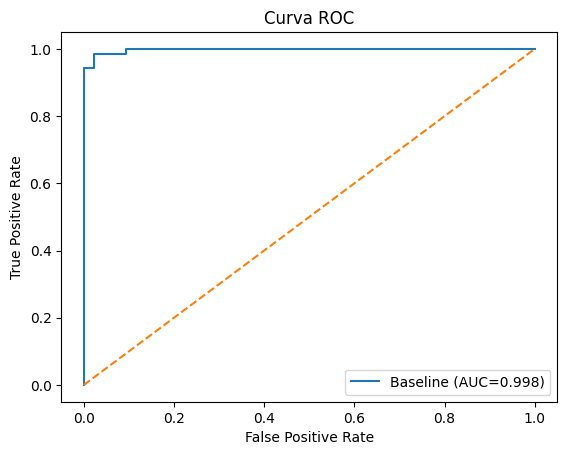

In [6]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba_struct)

plt.figure()
plt.plot(fpr, tpr, label="Baseline (AUC=0.998)")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

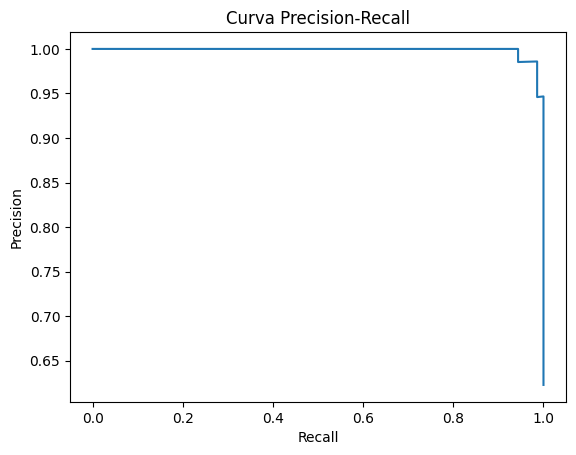

In [7]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba_struct)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()

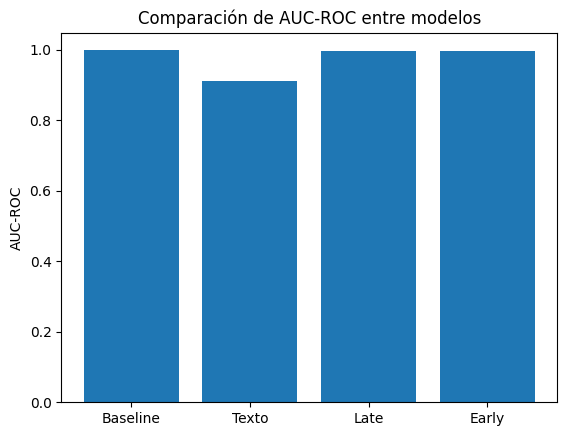

In [8]:
import matplotlib.pyplot as plt

modelos = ["Baseline", "Texto", "Late", "Early"]
auc_scores = [baseline[0], text[0], late[0], early[0]]

plt.figure()
plt.bar(modelos, auc_scores)
plt.title("Comparación de AUC-ROC entre modelos")
plt.ylabel("AUC-ROC")
plt.show()

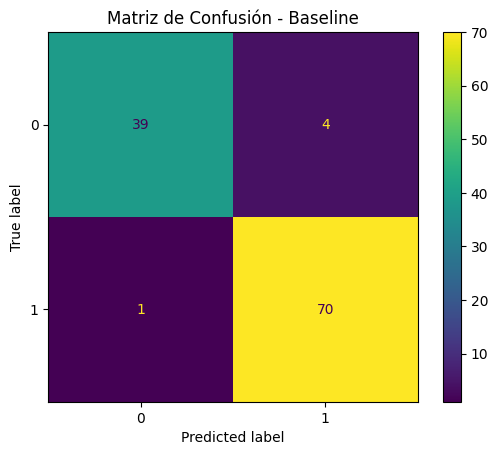

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_struct)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión - Baseline")
plt.show()